# Lab 05: Vectorized SVM Training

**Course:** Deep Learning for Computer Vision — 2026  
**Lecture connection:** Lecture 3B  
**Duration:** 90 minutes

This lab focuses on one main coding task: vectorizing the regularized SVM
loss and gradient. The loop-based reference and training pipeline are supplied
so you can spend the session understanding and validating the core equations.


## 1. Setup and supplied reference

Before running any cell, select the **Python (DLCV 2026)** kernel. If it is
missing, follow `Labs/README.md` from the repository root.

**Google Colab:** upload the complete `Lab05` folder, including
`linear_classifier.py` and the `dlcv2026` folder. You may place it at
`/content/Lab05`; the setup cell detects that location. Uploading only the
notebook will make the local imports fail.

The notebook follows the progression of the original course material while
keeping the workload realistic for one 90-minute lab. The completed
`svm_loss_naive`, minibatch sampler, SGD loop, and prediction helper are
supplied for inspection and use. Your only implementation task is
`svm_loss_vectorized` in `linear_classifier.py`. Save that file and rerun the
relevant validation cell. Autoreload plus explicit `importlib.reload` calls
make saved changes visible in local Jupyter and Google Colab.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import importlib
import sys
import time

import matplotlib.pyplot as plt
import torch

candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "Labs" / "Lab05",
    Path.cwd() / "Lab05",
    Path.cwd()
    / "Deep-Learning-for-Computer-Vision"
    / "Labs"
    / "Lab05",
]
lab_dir = next(
    (
        path.resolve()
        for path in candidate_dirs
        if (path / "linear_classifier.py").is_file()
        and (path / "dlcv2026").is_dir()
    ),
    None,
)
if lab_dir is None:
    raise FileNotFoundError(
        "Could not find the Lab05 support files. Keep linear_classifier.py "
        "and the dlcv2026 folder together with the notebook."
    )
if str(lab_dir) not in sys.path:
    sys.path.insert(0, str(lab_dir))

import dlcv2026
import linear_classifier

importlib.reload(linear_classifier)

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

print("PyTorch:", torch.__version__)
print("Lab directory:", lab_dir)
print("Implementation:", Path(linear_classifier.__file__).resolve())


PyTorch: 2.14.0+cpu
Lab directory: C:\Users\Deerman\OneDrive\Desktop\New folder\Deep-Learning-for-Computer-Vision\Labs\Lab05
Implementation: C:\Users\Deerman\OneDrive\Desktop\New folder\Deep-Learning-for-Computer-Vision\Labs\Lab05\linear_classifier.py


## 2. Review the supplied regularized SVM reference

Lecture 3B adds a penalty for large weights. The supplied
`svm_loss_naive` implements

$$
L = L_{\text{data}} + \lambda\sum_{d,c} W_{d,c}^2,
\qquad
\nabla_W L = \nabla_W L_{\text{data}} + 2\lambda W.
$$

The course convention does not multiply the regularization term by one half.
The fixture below has data loss `2.0` and `sum(W * W) == 4.0`, so `reg=0.1`
produces total loss `2.4`. Run the check, then locate the matching loss and
gradient lines in `svm_loss_naive`. You do not need to edit that function.


In [2]:
importlib.reload(linear_classifier)

X_fixture = torch.tensor([[1.0, 0.0], [0.0, 1.0], [-1.0, -1.0]])
W_fixture = torch.tensor([[1.0, -1.0, 0.0], [0.0, 1.0, -1.0]])
y_fixture = torch.tensor([2, 0, 1], dtype=torch.int64)

data_loss, data_gradient = linear_classifier.svm_loss_naive(
    W_fixture.clone(), X_fixture, y_fixture, reg=0.0
)
regularized_loss, regularized_gradient = linear_classifier.svm_loss_naive(
    W_fixture.clone(), X_fixture, y_fixture, reg=0.1
)

print("data loss:", float(data_loss))
print("regularized loss:", float(regularized_loss))
assert torch.allclose(data_loss, torch.tensor(2.0), atol=1e-12)
assert torch.allclose(regularized_loss, torch.tensor(2.4), atol=1e-12)
assert torch.allclose(
    regularized_gradient - data_gradient,
    2 * 0.1 * W_fixture,
    atol=1e-12,
)


data loss: 2.0
regularized loss: 2.4


### Validate the supplied reference

The centered finite-difference check demonstrates how we verify that L2 was
added to both the loss and the gradient. This cell is a validation example,
not an additional coding task.


In [3]:
importlib.reload(linear_classifier)

torch.manual_seed(6)
X_check = torch.randn(7, 5)
W_check = 0.1 * torch.randn(5, 4)
y_check = torch.tensor([0, 1, 2, 3, 0, 1, 2], dtype=torch.int64)

_, grad_check = linear_classifier.svm_loss_naive(
    W_check, X_check, y_check, reg=0.03
)
f = lambda weights: linear_classifier.svm_loss_naive(
    weights, X_check, y_check, reg=0.03
)[0]
errors = dlcv2026.grad_check_sparse(
    f, W_check, grad_check, num_checks=10, h=1e-6
)
print("maximum relative error:", max(errors))
assert max(errors) < 1e-5


index=(3, 3) numerical=+1.9396434e-02 analytic=+1.9396434e-02 relative_error=5.847e-09
index=(0, 2) numerical=-1.4354048e+00 analytic=-1.4354048e+00 relative_error=1.317e-10
index=(4, 3) numerical=+2.8982035e-01 analytic=+2.8982035e-01 relative_error=7.228e-10
index=(3, 2) numerical=+7.4215280e-01 analytic=+7.4215280e-01 relative_error=1.207e-10
index=(3, 2) numerical=+7.4215280e-01 analytic=+7.4215280e-01 relative_error=1.207e-10
index=(4, 1) numerical=+1.1345541e+00 analytic=+1.1345541e+00 relative_error=3.364e-11
index=(4, 1) numerical=+1.1345541e+00 analytic=+1.1345541e+00 relative_error=3.364e-11
index=(2, 1) numerical=-1.2702303e+00 analytic=-1.2702303e+00 relative_error=5.274e-11
index=(0, 2) numerical=-1.4354048e+00 analytic=-1.4354048e+00 relative_error=1.317e-10
index=(4, 1) numerical=+1.1345541e+00 analytic=+1.1345541e+00 relative_error=3.364e-11
maximum relative error: 5.846888518526385e-09


## 3. Vectorize the SVM loss and gradient

Complete `svm_loss_vectorized` without Python loops. Build an $(N,C)$
margin matrix, zero the correct-class entries, and reuse a coefficient matrix
to compute the gradient with one matrix multiplication.

### Matrix multiplication notation

For the two-dimensional PyTorch tensors in this lab, these are equivalent:

```python
scores = X @ W
scores = torch.matmul(X, W)
```

Both produce a score matrix with shape $(N,C)$ from `X` with shape $(N,D)$
and `W` with shape $(D,C)$. You may use either form. Do not use
`X * W`, which means elementwise multiplication.


In [4]:
importlib.reload(linear_classifier)

torch.manual_seed(7)
X_small = torch.randn(8, 5)
W_small = 0.05 * torch.randn(5, 4)
y_small = torch.tensor([0, 1, 2, 3, 0, 2, 1, 3], dtype=torch.int64)

loss_naive, grad_naive = linear_classifier.svm_loss_naive(
    W_small, X_small, y_small, reg=0.05
)
loss_vectorized, grad_vectorized = linear_classifier.svm_loss_vectorized(
    W_small, X_small, y_small, reg=0.05
)

print("loss difference:", float((loss_naive - loss_vectorized).abs()))
print("gradient max difference:", float((grad_naive - grad_vectorized).abs().max()))
assert torch.allclose(loss_naive, loss_vectorized, atol=1e-10)
assert torch.allclose(grad_naive, grad_vectorized, atol=1e-10)


loss difference: 4.440892098500626e-16
gradient max difference: 2.7755575615628914e-16


### Timing comparison

Run this after the correctness check. CPU timing varies, so focus on the
relative behavior rather than a fixed millisecond target.


In [5]:
importlib.reload(linear_classifier)

torch.manual_seed(8)
X_speed = torch.randn(512, 128)
W_speed = 0.01 * torch.randn(128, 10)
y_speed = torch.randint(0, 10, (512,))

start = time.perf_counter()
linear_classifier.svm_loss_naive(W_speed, X_speed, y_speed, reg=1e-3)
naive_seconds = time.perf_counter() - start

start = time.perf_counter()
linear_classifier.svm_loss_vectorized(
    W_speed, X_speed, y_speed, reg=1e-3
)
vectorized_seconds = time.perf_counter() - start

print(f"naive: {naive_seconds:.4f}s")
print(f"vectorized: {vectorized_seconds:.4f}s")
print(f"speedup: {naive_seconds / max(vectorized_seconds, 1e-12):.1f}x")


naive: 0.1310s
vectorized: 0.0072s
speedup: 18.2x


## 4. Inspect the supplied training pipeline

Read `sample_batch` and `train_linear_classifier` in `linear_classifier.py`.
The code samples with replacement and applies $W \leftarrow W - \eta\nabla_W L$.
Both functions are supplied because optimizer implementation belongs to the
Lecture 4 labs. The cell below is only a smoke test of minibatch sampling.


In [6]:
importlib.reload(linear_classifier)

X_index = torch.arange(30, dtype=torch.float64).reshape(10, 3)
y_index = torch.arange(10, dtype=torch.int64)
generator = torch.Generator().manual_seed(3)
X_batch, y_batch = linear_classifier.sample_batch(
    X_index, y_index, 6, generator
)

print("batch labels:", y_batch.tolist())
assert X_batch.shape == (6, 3)
assert y_batch.shape == (6,)
assert torch.equal(X_batch[:, 0] / 3, y_batch.to(torch.float64))


batch labels: [6, 8, 7, 7, 0, 0]


## 5. Use the supplied pipeline to train and evaluate an SVM

The supplied dataset is deterministic, small, and download-free. Its final
feature is a constant one, so the last row of $W$ acts as the bias.


X_train (360, 3)
y_train (360,)
X_val (120, 3)
y_val (120,)


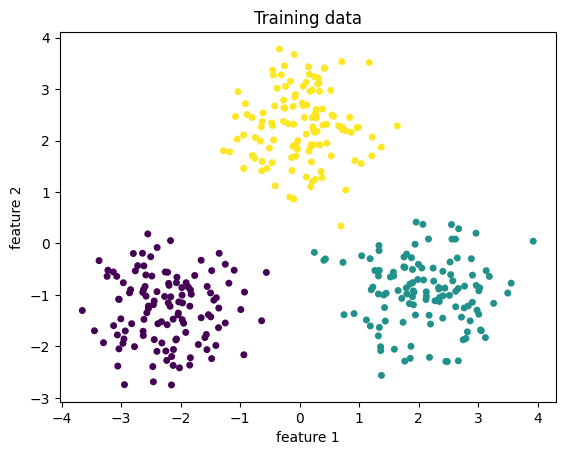

In [7]:
data = dlcv2026.make_toy_classification(seed=11)
for name, value in data.items():
    print(name, tuple(value.shape))

plt.scatter(
    data["X_train"][:, 0],
    data["X_train"][:, 1],
    c=data["y_train"],
    cmap="viridis",
    s=16,
)
plt.title("Training data")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()


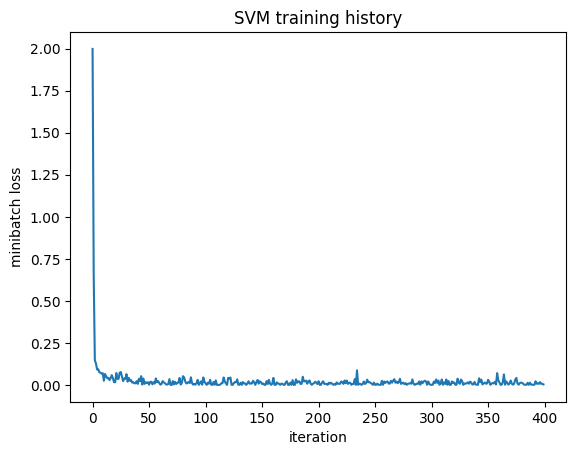

training accuracy: 99.72%
validation accuracy: 100.00%


In [8]:
importlib.reload(linear_classifier)

W_trained, loss_history = linear_classifier.train_linear_classifier(
    linear_classifier.svm_loss_vectorized,
    data["X_train"],
    data["y_train"],
    learning_rate=0.08,
    reg=1e-3,
    num_iters=400,
    batch_size=64,
    seed=5,
)

plt.plot(loss_history)
plt.xlabel("iteration")
plt.ylabel("minibatch loss")
plt.title("SVM training history")
plt.show()

train_predictions = linear_classifier.predict_linear_classifier(
    W_trained, data["X_train"]
)
val_predictions = linear_classifier.predict_linear_classifier(
    W_trained, data["X_val"]
)
train_accuracy = linear_classifier.accuracy(
    train_predictions, data["y_train"]
)
val_accuracy = linear_classifier.accuracy(
    val_predictions, data["y_val"]
)
print(f"training accuracy: {100 * train_accuracy:.2f}%")
print(f"validation accuracy: {100 * val_accuracy:.2f}%")

assert loss_history[-1] < loss_history[0]
assert val_accuracy > 0.85


## 6. Regularization experiment

The cell below changes only the regularization strength. Because the seed,
initial weights, minibatches, learning rate, and iteration count stay the
same, the comparison isolates the effect of stronger L2 regularization.


In [9]:
importlib.reload(linear_classifier)

W_strong_reg, strong_reg_history = (
    linear_classifier.train_linear_classifier(
        linear_classifier.svm_loss_vectorized,
        data["X_train"],
        data["y_train"],
        learning_rate=0.08,
        reg=1.0,
        num_iters=400,
        batch_size=64,
        seed=5,
    )
)

strong_reg_predictions = linear_classifier.predict_linear_classifier(
    W_strong_reg, data["X_val"]
)
strong_reg_accuracy = linear_classifier.accuracy(
    strong_reg_predictions, data["y_val"]
)
baseline_norm = torch.linalg.vector_norm(W_trained).item()
strong_reg_norm = torch.linalg.vector_norm(W_strong_reg).item()

print(f"baseline validation accuracy: {100 * val_accuracy:.2f}%")
print(f"strong-reg validation accuracy: {100 * strong_reg_accuracy:.2f}%")
print(f"baseline weight norm: {baseline_norm:.4f}")
print(f"strong-reg weight norm: {strong_reg_norm:.4f}")

assert strong_reg_norm < baseline_norm


baseline validation accuracy: 100.00%
strong-reg validation accuracy: 100.00%
baseline weight norm: 1.5777
strong-reg weight norm: 0.5398


## 7. Wrap-up

Answer briefly in a new Markdown cell:

1. Why should the vectorized and naive losses agree?
2. Why is a minibatch loss curve noisier than a full-dataset loss curve?
3. Why did stronger L2 regularization reduce the weight norm?

**Optional homework:** run a small grid search over learning rate and
regularization, then repeat the experiment on a CIFAR-10 subset.


1. Why should the vectorized and naive losses agree?

Both versions calculate the exact same formula, they just do it in different ways. The naive version uses loops to go through each example one at a time, while the vectorized version uses matrix operations to compute everything at once. Since the underlying math is identical, the two methods should produce the same loss and gradient values (aside from tiny rounding differences from floating-point math).

2. Why is a minibatch loss curve noisier than a full-dataset loss curve?

A minibatch is just a small random sample of the training data, so its loss changes depending on which examples happen to be picked each time. Some batches might contain harder examples, making the loss look higher, while others might contain easier ones, making it look lower — even if the model isn't actually getting worse or better. A full-dataset loss, on the other hand, uses every example each time, so these random ups and downs even out, giving a smoother curve.

3. Why did stronger L2 regularization reduce the weight norm?

L2 regularization adds a penalty based on how large the weights are — bigger weights mean a bigger penalty added to the loss. When we increase the regularization strength, that penalty becomes more significant, so the training process pushes the weights to become smaller in order to keep the total loss low. This is why increasing regularization leads to smaller overall weight values.